In [1]:
from openalea.hydroroot.millet import architecture, turtle, law
from matplotlib import pyplot
from openalea.hydroroot import length
from openalea.plantgl.all import Viewer


In [2]:
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


Distribution of lateral root length 
---------------------------------------

(array([33.,  6.,  4.,  0.,  0.,  2.,  1.,  0.,  0.,  1.]),
 array([1.90221246e-05, 1.08761527e-02, 2.17332832e-02, 3.25904138e-02,
        4.34475443e-02, 5.43046749e-02, 6.51618055e-02, 7.60189360e-02,
        8.68760666e-02, 9.77331971e-02, 1.08590328e-01]),
 <BarContainer object of 10 artists>)

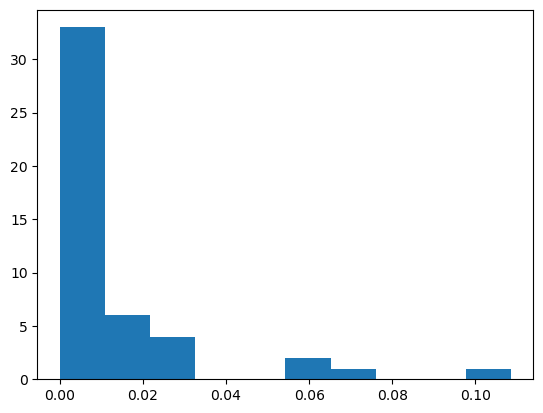

In [3]:

import numpy as np
import random
filename = 'lr_length_law_data.csv'
csvdata = np.recfromcsv(filename,delimiter=';')

x_name = csvdata.dtype.names[0]
y_name = csvdata.dtype.names[1]

x = list(csvdata[x_name])
y = list(csvdata[y_name])

x = list(array(x)*1.e-2) # convert variables to meters
y = list(array(y)*1.e-2) # convert variables to meters

d= zip(x,y)

d= dict(d)

x= sorted(d.keys())
y= [d[k] for k in x]

l=[]
geom = {}
liste = []

assert len(x)== len(y)
for i in range(0,len(x),5):
    if i==0:
        continue
    k= [x[i] for i in range(i-5,i)] # slice positions into 5cm-segments
    p = 1./(np.array([y[i] for i in range(i-5,i)]).mean()) #for each segment, compute its mean and its inverse as input parameter for exponantial law
    liste.append(p)
    l.append(random.expovariate(p))
    geom[random.expovariate(p)] = k
    
    
def LR_length_law(pos,data = geom):
    LR_length = 0
    for i,j in data.iteritems():
        if pos in j:
            LR_length = i
    return LR_length
    

#plot(x,y,'bo')
hist(l)
#print liste


#print geom

# Compute a law (continuous function) from discrete measured data
   * Read the csv file
   * Interpolate the data to build a function

# Hypothesis:
   * Absolute domain $[0, L]$ rather than $[0, 1]$
   * Continuous ($C^1$) law



/tmp/ipykernel_150567/3486030159.py:65: RuntimeWarning: divide by zero encountered in double_scalars
  YY = [random.expovariate(1/v) for v in Y]


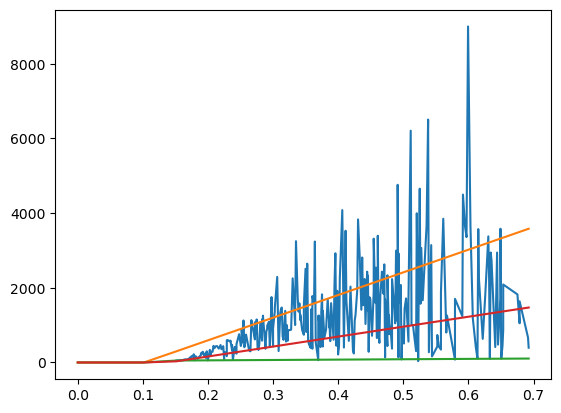

In [9]:
import numpy as np
import random
from openalea.hydroroot.read_file import readCSVFile
from openalea.hydroroot import length
import pylab

# read csv file
filename = 'lr_length_law_data.csv'
xy = readCSVFile(filename)
# sort by position 
xy.sort(axis=0)
xy = xy.tolist()
x, y = zip(*xy)  # Separate x and y coordiantes
x = np.array(x)*1e-2
y = np.array(y)*1e3
x=x.tolist()
y=y.tolist()

#print min(x),max(x)

# Segment the data with a sliding window of 5 cm
pyplot.plot(x,y)

def segment(x, y, size=5e-2):
    """ Segment by centered interval:
    (min, min+size)
    (min+size +- size/2.)
    ...
    (max-size, max)
    """
    m, M = x[0], x[-1]
    ds = size/2
    step = int((M-m)/5.)

    points = [(m+i*size) for i in range(1,step)]

    intervals = [(m, m+size)] + [(p-ds, p+ds) for p in points]+[(M-size, M)]

    ys = [[y[i] for i,p in enumerate(x) if i0 <= p <= i1] for i0, i1 in intervals]
    points.insert(0,m)
    points.append(M)
    
    points.insert(0, m-size)
    ys.insert(0, [0.])
    points.insert(0, 0.)
    ys.insert(0, [0.])
    
    return points, ys

#Yt= segment(x,y)[1]
#print Yt

Y = [max(ys) for ys in segment(x,y)[1]]
X = segment(x,y)[0]
pylab.plot(X,Y)
YY = Y
#for i in range(5):
    #YY = [random.expovariate(1/v) for v in Y]
    #pylab.plot(X,YY)
Y = [min(ys) for ys in segment(x,y)[1]]
pylab.plot(X,Y)

# Estimate a stat law and reconstruct a continuous law
Y = [np.median(ys) for ys in segment(x,y)[1]]
YY = [random.expovariate(1/v) for v in Y]

pylab.plot(X,YY)

law = length.fit_law(X, YY)
LR_length_law = law



In [10]:
from IPython.display import *

In [6]:
FileLinks('.')

./
  CR_diameters.csv
  tmp_Water_flux_nb.py
  Water flux-bckup.ipynb
  SR_diameters.csv
  Water flux-Copy1.ipynb
  toto.png
  Millet Root Model-bckup.ipynb
  tmp.py
  Millet Root Model.ipynb
  Water flux-Copy1-bckup.ipynb
  lr_length_law_data.csv
  mtg.pov
  Water flux.ipynb
  LR_diameters.csv
./.ipynb_checkpoints/
  Water flux-Copy1-bckup-checkpoint.ipynb
  Water flux-checkpoint.ipynb
  Water flux-Copy1-checkpoint.ipynb
  lr_length_law_data-checkpoint.csv
  Millet Root Model-checkpoint.ipynb
  Millet Root Model-bckup-checkpoint.ipynb
  Water flux-bckup-checkpoint.ipynb

In [ ]:
g = architecture.millet_mtg(LR_length_law = LR_length_law, nb_vertices=150)

In [ ]:
import math

seminal_RootDiameter_law = lambda x: 70.42*math.log(x) + 282.45
crown_RootDiameter_law = lambda x: 59.15*math.log(x) + 416.57
lr_RootDiameter_law = lambda x: 29.95*math.log(x) + 286.32

In [ ]:
g = architecture.compute_diameter(g, 
                                   seminal_RootDiameter_law = seminal_RootDiameter_law,
                                   crown_RootDiameter_law = crown_RootDiameter_law,
                                   lr_RootDiameter_law = lr_RootDiameter_law)

In [ ]:
g= architecture.radius_from_computed_diameters(g) # for radius computation

In [ ]:
# ' < '.join(g.label(v) for v in g.Trunk(1))

In [ ]:
len(g)

In [ ]:
len(g.Trunk(1))

In [ ]:
g = architecture.developmental_age(g,15)

In [ ]:
%gui qt

In [ ]:
from openalea.hydroroot.millet import turtle

In [ ]:
ages = g.property('age')
age_max = max(ages.values())

In [ ]:
print age_max

t= age_max

In [19]:
#for t in range(1, age_max, 1):
    #g, scene = turtle.mtg_turtle_time(g,t)
    #turtle.Plot(scene)
g, scene = turtle.mtg_turtle_time(g,t)    
turtle.Plot(scene)

openalea.plantgl:86: Warning: <Oriented> Field 'Primary' has a bad value : Must be normalized.
openalea.plantgl:281: Warning: <Shape> Field 'Geometry' has a bad value : Must be valid.
openalea.plantgl:418: Warning: <Scene> Field 'ShapeList' has a bad '8857'th value : Must be a valid Shape.


In [24]:
#turtle.Viewer.saveSnapshot('toto.png')

In [25]:
'%03d'%100

'100'

In [22]:
a=turtle.PglTurtle()

In [23]:
for t in range(1, 352):
    g, scene = turtle.mtg_turtle_time(g,t)
    turtle.Plot(scene)

In [22]:
%%timeit
turtle.mtg_turtle_time(g,t)

100 loops, best of 3: 15 ms per loop


In [18]:
n5=g.node(1774)

In [23]:
n5.position?

Object `n5.position` not found.


In [21]:
n5.order

1

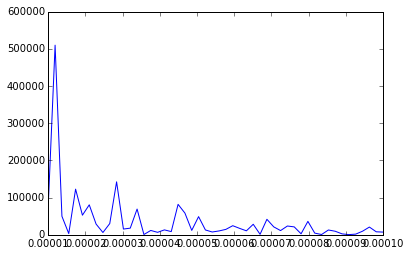

In [62]:
x = np.linspace(0.00001,0.0001)
y = map(random.expovariate, x)
pylab.plot(x,y)

In [37]:
m, M = x[0], x[-1]
size = 5e-2
ds = size/2.
step = int((M-m)/5)

points = [(m+i*size) for i in range(1,step)]
print points
#print M,m,step

intervals = [(m, m+size)] + [(p-ds, p+ds) for p in points]+[(M-size, M)]

print intervals

ys = [[y[i] for i,p in enumerate(x) if i0 <= p <= i1] for i0, i1 in intervals]
ys.insert(0,[0.])
ys.insert(0,[0.])
print ys


ys = [[y[i] for i,p in enumerate(x) if i0 <= p <= i1] for i0, i1 in intervals]
ys.insert(0, [0.])
points.insert(0, 0.)
ys.insert(0, [0.])
#print ys

def select(x, interval):
    i0, i1 = interval
    return [p for p in x if i0 <= p <= i1]
#print [select(x, interval) for interval in intervals]

[]
[(0.1665045, 0.2165045), (0.5747769199999999, 0.62477692)]
[[0.0], [0.0], [39.881017, 46.18338, 79.081155, 72.34384, 137.40474, 69.56084, 164.85733, 198.63716, 100.02789, 180.42925000000002, 210.19082, 283.87010000000004, 166.32274999999998, 89.27546, 163.30647000000002, 246.91334, 253.50073, 117.41016, 303.88140000000004, 369.2414, 215.53819, 274.01439999999997, 86.46468999999999, 253.42712, 110.644296, 363.01053, 276.6852, 355.0021, 84.71802600000001, 367.04062999999996, 388.03294, 406.3922], [179.51116, 4801.725399999999, 690.22006, 300.4743, 458.39414, 1738.6562000000001, 2036.055, 407.00597, 189.56064, 329.9568, 476.76039999999995, 342.0892, 2623.6446, 1308.5176999999999, 2157.7022, 16063.845000000001, 5072.1736]]
